In [8]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Đưa đường dẫn thư mục gốc vào hệ thống để gọi module core_ntsa
sys.path.append(os.path.abspath(".."))

from core_ntsa.dynamics_noise import simulate_lorenz_sde
from core_ntsa.generators import simulate_lorenz
from core_ntsa.noise_tools import add_white_noise

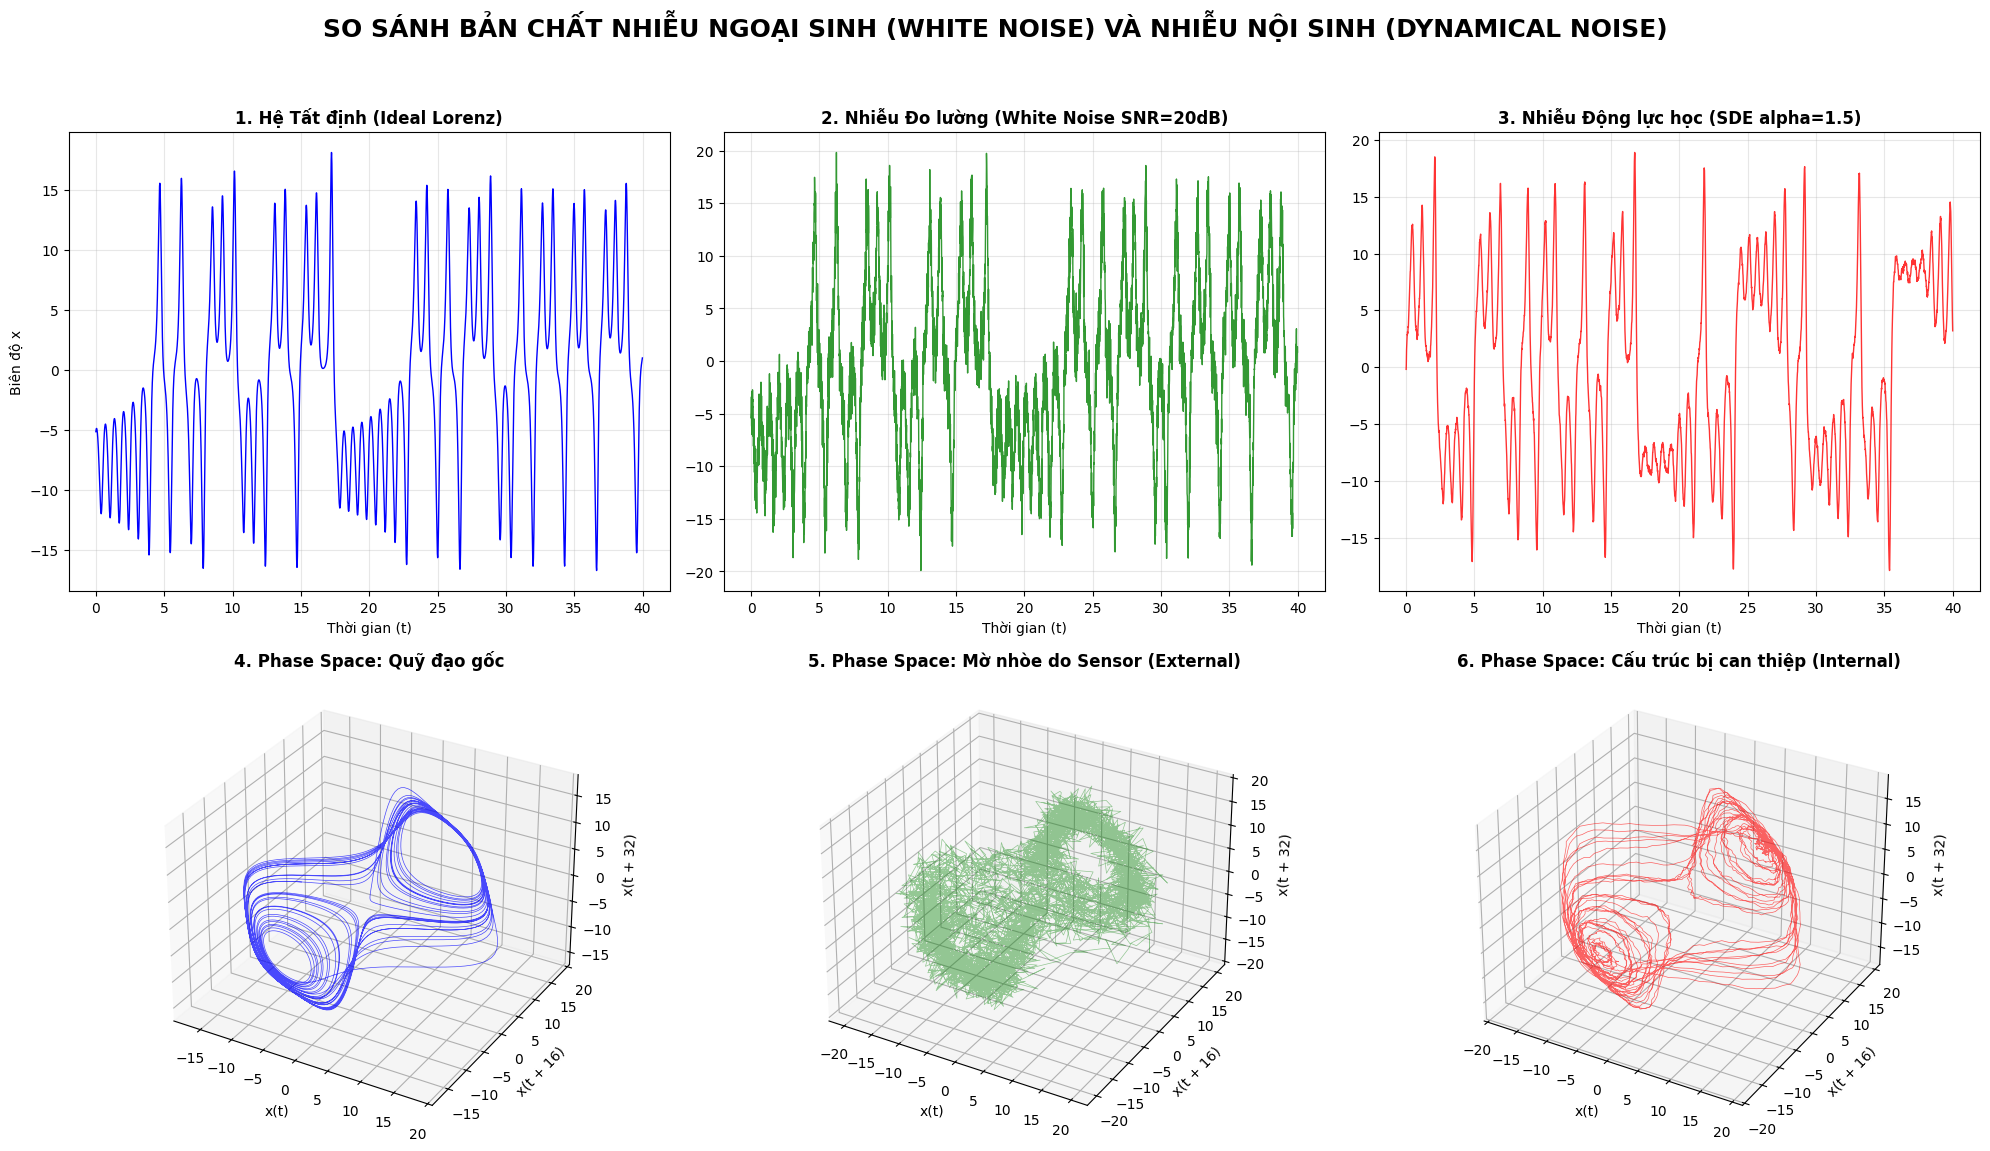

In [10]:
# --- BẮT ĐẦU PHẦN CODE VIẾT THÊM ---

# 1. Cấu hình tham số mô phỏng
t_span = 50.0  # Chạy trong 50s để có đủ điểm vẽ không gian pha
dt = 0.01
transient_drop = 1000

# Tham số không gian pha
m = 3
tau = 16

# 2. Khởi tạo dữ liệu
# Sinh chuỗi Lorenz tất định (chuẩn)
lorenz_det = simulate_lorenz(t_span=t_span, dt=dt, transient_drop=transient_drop)
x_det = lorenz_det[0, :]  # Lấy thành phần x

# Sinh chuỗi Lorenz chứa nhiễu động lực học (SDE)
noise_level = 1.5 # Có thể tinh chỉnh mức độ nhiễu này để quan sát
lorenz_sde = simulate_lorenz_sde(t_span=t_span, dt=dt, transient_drop=transient_drop, noise_intensity=noise_level, seed=42)
x_sde = lorenz_sde[0, :]


white_noise = add_white_noise(lorenz_det, snr_db=20.0)
x_white_noise = white_noise[0, :]
# Trục thời gian chung
time_axis = np.arange(len(x_det)) * dt

# 4. Hàm tái tạo không gian pha (Takens' Embedding Theorem)
def reconstruct_phase_space(ts, m, tau):
    """
    Tái tạo không gian pha từ chuỗi thời gian 1D bằng vector trễ.
    """
    N = len(ts)
    N_m = N - (m - 1) * tau
    embedded = np.zeros((N_m, m))
    for i in range(m):
        embedded[:, i] = ts[i*tau : i*tau + N_m]
    return embedded

# Tạo ma trận nhúng cho cả 3 trường hợp
embedded_det = reconstruct_phase_space(x_det, m, tau)
embedded_wn  = reconstruct_phase_space(x_white_noise, m, tau)
embedded_sde = reconstruct_phase_space(x_sde, m, tau)

# 5. Trực quan hóa (Plotting 2x3 Grid)
fig = plt.figure(figsize=(20, 12)) # Tăng chiều ngang để chứa 3 cột
fig.suptitle("SO SÁNH BẢN CHẤT NHIỄU NGOẠI SINH (WHITE NOISE) VÀ NHIỄU NỘI SINH (DYNAMICAL NOISE)", 
             fontsize=18, fontweight='bold')

# ================= HÀNG 1: CHUỖI THỜI GIAN (TIME SERIES) =================

# 1A. Hệ Tất định (Deterministic)
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(time_axis, x_det, color='blue', lw=1)
ax1.set_title("1. Hệ Tất định (Ideal Lorenz)", fontweight='bold')
ax1.set_xlabel("Thời gian (t)")
ax1.set_ylabel("Biên độ x")
ax1.grid(True, alpha=0.3)

# 1B. Nhiễu Ngoại sinh (Additive White Noise)
ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(time_axis, x_white_noise, color='green', lw=1, alpha=0.8)
ax2.set_title("2. Nhiễu Đo lường (White Noise SNR=20dB)", fontweight='bold')
ax2.set_xlabel("Thời gian (t)")
ax2.grid(True, alpha=0.3)

# 1C. Nhiễu Nội sinh (Dynamical Noise / SDE)
ax3 = fig.add_subplot(2, 3, 3)
ax3.plot(time_axis, x_sde, color='red', lw=1, alpha=0.8)
ax3.set_title(f"3. Nhiễu Động lực học (SDE alpha={noise_level})", fontweight='bold')
ax3.set_xlabel("Thời gian (t)")
ax3.grid(True, alpha=0.3)

# ================= HÀNG 2: KHÔNG GIAN PHA (PHASE SPACE) =================

# 2A. Không gian pha - Tất định
ax4 = fig.add_subplot(2, 3, 4, projection='3d')
ax4.plot(embedded_det[:, 0], embedded_det[:, 1], embedded_det[:, 2], color='blue', lw=0.5, alpha=0.7)
ax4.set_title("4. Phase Space: Quỹ đạo gốc", fontweight='bold')
ax4.set_xlabel("x(t)")
ax4.set_ylabel(f"x(t + {tau})")
ax4.set_zlabel(f"x(t + {2*tau})")

# 2B. Không gian pha - White Noise
ax5 = fig.add_subplot(2, 3, 5, projection='3d')
ax5.plot(embedded_wn[:, 0], embedded_wn[:, 1], embedded_wn[:, 2], color='green', lw=0.5, alpha=0.4)
ax5.set_title("5. Phase Space: Mờ nhòe do Sensor (External)", fontweight='bold')
ax5.set_xlabel("x(t)")
ax5.set_ylabel(f"x(t + {tau})")
ax5.set_zlabel(f"x(t + {2*tau})")

# 2C. Không gian pha - Dynamical Noise
ax6 = fig.add_subplot(2, 3, 6, projection='3d')
ax6.plot(embedded_sde[:, 0], embedded_sde[:, 1], embedded_sde[:, 2], color='red', lw=0.5, alpha=0.6)
ax6.set_title("6. Phase Space: Cấu trúc bị can thiệp (Internal)", fontweight='bold')
ax6.set_xlabel("x(t)")
ax6.set_ylabel(f"x(t + {tau})")
ax6.set_zlabel(f"x(t + {2*tau})")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### NHẬN XÉT: SỰ KHÁC BIỆT BẢN CHẤT GIỮA NHIỄU NGOẠI SINH VÀ NỘI SINH

**1. Nhiễu Ngoại sinh (White Noise / Measurement Noise)**
* **Chuỗi thời gian:** Xuất hiện các "gai" nhiễu bề mặt, nhưng tiến trình và *thời điểm chuyển pha hoàn toàn không thay đổi*.
* **Không gian pha:** Tạo thành một "đám mây mờ" bao quanh quỹ đạo, nhưng cấu trúc hình học cốt lõi vẫn được giữ nguyên.
* **Bản chất:** Là sai số đo lường (rung lắc cơ học, nhiễu cảm biến). Hoàn toàn có thể loại bỏ bằng các bộ lọc tần số tiêu chuẩn.

**2. Nhiễu Nội sinh (Dynamical Noise / SDE)**
* **Chuỗi thời gian:** Tín hiệu giữ được độ mượt, nhưng *tiến trình thời gian bị xô đẩy liên tục* (làm thay đổi số vòng lặp và thời điểm đảo pha).
* **Không gian pha:** Quỹ đạo "lang thang" ra khỏi đường mòn lý thuyết, làm biến dạng ranh giới và nới lỏng cấu trúc từ bên trong.
* **Bản chất:** Nhiễu can thiệp trực tiếp vào phương trình tiến hóa của hệ thống. Không thể lọc bỏ bằng các phương pháp xử lý tín hiệu truyền thống.

**💡 Ý nghĩa đối với bài toán PPG:**
Sự chuyển đổi từ Tỉnh táo (Awake) sang Buồn ngủ (Drowsy) thực chất là sự thay đổi cấu trúc của nhiễu nội sinh do hệ thần kinh tự chủ (ANS) giảm khả năng điều hòa. Việc áp dụng các phương pháp đo lường hình học trực tiếp như **Spline Analysis** sẽ giúp định lượng chính xác sự "biến dạng" và "lang thang" trong không gian pha này.